In [1]:
"""
Combines *_category_tests.csv files into a DataFrame loadable from this notebook.
"""

import re
from pathlib import Path

import pandas as pd

UNPREFIXED_NAME = re.compile(r"^q\d+_.*__category_tests\.csv$")


def combine_significance(root_dir: Path, output_dir: Path, write_files: bool = False):
    """Combines the files and returns (combined_df, summary_df).
    If write_files=True, also saves CSVs to output_dir.
    """
    all_files = sorted(root_dir.glob("significance_*/*category_tests*.csv"))

    if not all_files:
        all_files = sorted(root_dir.rglob("*category_tests*.csv"))

    files = [f for f in all_files if UNPREFIXED_NAME.match(f.name)]

    skipped = [f for f in all_files if f not in files]
    if skipped:
        print(f"Skipped {len(skipped)} files with a model prefix (not combined):")
        for f in skipped:
            print(f"  - {f}")

    if not files:
        print(f"No unprefixed *category_tests*.csv found inside {root_dir}")
        return pd.DataFrame(), pd.DataFrame()

    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["source_folder"] = f.parent.name
        dfs.append(df)
        print(f"Read: {f}  ({len(df)} rows)")

    combined = pd.concat(dfs, ignore_index=True)

    key_cols = ["question_key", "model_alias", "attribute", "category_value", "group_value"]
    before = len(combined)
    combined = combined.drop_duplicates(subset=key_cols, keep="first")
    if len(combined) < before:
        print(f"Removed {before - len(combined)} duplicate rows (files repeated with/without prefix).")

    combined["significant"] = combined["reject_fdr"].map({True: "Yes", False: "No"})

    combined = combined.sort_values(
        ["model_alias", "question_key", "attribute", "category_value", "group_value"]
    ).reset_index(drop=True)

    summary = (
        combined.groupby(["model_alias", "question_key", "attribute"])["reject_fdr"]
        .agg(total_tests="count", significant="sum")
        .reset_index()
    )

    if write_files:
        output_dir.mkdir(parents=True, exist_ok=True)
        out_path = output_dir / "combined_category_tests.csv"
        combined.to_csv(out_path, index=False)
        summary_path = output_dir / "significance_summary.csv"
        summary.to_csv(summary_path, index=False)
        print(f"Saved CSVs to: {output_dir}")

    return combined, summary


# --- Generate combined in memory (CSVs are not saved by default) ---
# The *_category_tests.csv files live under results_merged/frequency_tables/significance_tests/,
# one per model (deepseek-v4-flash_paid, gemma-4-31b_paid, ...) plus an all_models/ folder
# with the pooled test (all models combined into a single pseudo-model row).
# (by_model/ only has *_frequency.csv, not category_tests, so it doesn't interfere here.)
root_dir = Path("../results_merged/frequency_tables")
output_dir = Path("combined_significance")
combined_df, summary_df = combine_significance(root_dir, output_dir, write_files=False)

# "all_models" is the pooled test (all models combined), not a real model:
# we drop it so it doesn't show up as one more model in the comparisons.
n_before = len(combined_df)
combined_df = combined_df[combined_df["model_alias"] != "all_models"].reset_index(drop=True)
print(f"Excluded {n_before - len(combined_df)} rows from 'all_models' (pooled test, not a model).")
print(f"Combined in-memory: {len(combined_df)} rows")


Read: ..\results_merged\frequency_tables\significance_tests\all_models\q1_gender__category_tests.csv  (70 rows)
Read: ..\results_merged\frequency_tables\significance_tests\all_models\q1_race__category_tests.csv  (280 rows)
Read: ..\results_merged\frequency_tables\significance_tests\all_models\q2_gender__category_tests.csv  (42 rows)
Read: ..\results_merged\frequency_tables\significance_tests\all_models\q2_race__category_tests.csv  (168 rows)
Read: ..\results_merged\frequency_tables\significance_tests\deepseek-v4-flash_paid\q1_gender__category_tests.csv  (62 rows)
Read: ..\results_merged\frequency_tables\significance_tests\deepseek-v4-flash_paid\q1_race__category_tests.csv  (248 rows)
Read: ..\results_merged\frequency_tables\significance_tests\deepseek-v4-flash_paid\q2_gender__category_tests.csv  (38 rows)
Read: ..\results_merged\frequency_tables\significance_tests\deepseek-v4-flash_paid\q2_race__category_tests.csv  (152 rows)
Read: ..\results_merged\frequency_tables\significance_tests\

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUTPUT_DIR = Path("figures").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 6                      # the 6 most popular jobs/fields
EXCLUDE_REGIONS = {"Unknown"}  # regions to exclude from the plot

QUESTION_TITLES = {
    "q1": "Job Recommendation",
    "q2": "College Recommendation",
}

MODEL_COLORS = {
    "deepseek-v4-flash_paid": "#7b3fa0",
    "gemma-4-31b_paid": "#1b9e77",
    "glm-5.2_paid": "#e6ab02",
    "grok-4.3_paid": "#d94b4b",
    "gemma-4-e2b_modal": "#377eb8",
    "ministral-3-8b_modal": "#a6761d",
}
FALLBACK_COLORS = plt.cm.tab10.colors


def clean_model(name: str) -> str:
    return name.replace("_paid", "").replace("_modal", "")

In [3]:
df = combined_df.copy()


def prepare_region_data(df: pd.DataFrame, question: str) -> pd.DataFrame:
    """Race (=Region) rows with the % of each region's outputs that fall into each category."""
    sub = df[(df["question_key"] == question) & (df["attribute"] == "Race")].copy()
    sub = sub[~sub["group_value"].isin(EXCLUDE_REGIONS)]

    # % of that region's outputs that fall into this category
    sub["share_pct"] = sub["group_in_category"] / sub["group_total"] * 100
    sub["significant"] = sub["reject_fdr"].astype(bool)
    sub = sub.rename(columns={"group_value": "region"})
    return sub

# quick look
tmp = prepare_region_data(df, "q1")
print("Regions:", sorted(tmp["region"].unique()))
print("Models:", sorted(tmp["model_alias"].unique()))
print(f"{tmp['category_value'].nunique()} categories in q1")

Regions: ['Central/Eastern Europe', 'France', 'Germany', 'Hispanic Countries', 'MENA', 'South/Central Asia', 'Sub-Saharan Africa', 'United Kingdom / North America']
Models: ['deepseek-v4-flash_paid', 'gemma-4-31b_paid', 'gemma-4-e2b_modal', 'glm-5.2_paid', 'grok-4.3_paid', 'ministral-3-8b_modal']
35 categories in q1


In [4]:
def region_smallmultiples(df: pd.DataFrame, question: str, n_cols=3):
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())

    # Top N categories present in ALL models, by total size
    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )

    # p-values for the difference between models (Test 1)
    bm = between_model_rate_tests(df, question).set_index("category_value")

    def _fmt(p):
        return "n/a" if pd.isna(p) else ("p<0.001" if p < 0.001 else f"p={p:.3f}")

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(top_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(top_cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        # Alternating vertical bands to separate regions
        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=6.8,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.5, zorder=3)

        p1 = bm.loc[cat, "p_overall_rate_fdr"] if cat in bm.index else np.nan
        ax.set_title(f"{cat}\nModel difference: {_fmt(p1)}", fontsize=10)

        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=35, ha="right", fontsize=9)
        ax.grid(axis="y", color="0.9", zorder=0)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share of this region's outputs (%)", fontsize=10)

    for ax in axes[len(top_cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models",
                 fontsize=14, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    fig.legend(handles=handles, title="Model", loc="center left",
               bbox_to_anchor=(1.0, 0.5), fontsize=10, title_fontsize=10)

    fig.tight_layout(rect=[0, 0, 0.99, 0.95])
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out = (OUTPUT_DIR / f"region_smallmultiples_{question}_{title.lower().replace(' ', '_')}.png").resolve()
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

In [5]:
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests


def between_model_rate_tests(df, question, min_count=5):
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return pd.DataFrame()

    totals = (data.drop_duplicates(["model_alias", "region"])
                  .groupby("model_alias")["group_total"].sum())
    all_models = list(totals.index)               # <- fixed universe of models

    rows = []
    for cat, cdata in data.groupby("category_value"):
        per_model = cdata.groupby("model_alias")["group_in_category"].sum()
        # ALL models are included; those without this category -> 0 (that's meaningful data)
        counts = {m: int(per_model.get(m, 0)) for m in all_models}

        tab = np.array([[counts[m], totals[m] - counts[m]] for m in all_models])
        total_in_cat = tab[:, 0].sum()

        # with very small counts, use Fisher/Monte Carlo instead of asymptotic chi2
        if total_in_cat < min_count:
            p1 = np.nan                            # or fisher_exact / chi2 MonteCarlo
        else:
            p1 = chi2_contingency(tab)[1]

        rows.append({
            "category_value": cat,
            "total_in_category": int(total_in_cat),
            "p_overall_rate": p1,
            "rates_%": {clean_model(m): round(100*counts[m]/totals[m], 2)
                        for m in all_models},
        })

    res = pd.DataFrame(rows)
    mask = res["p_overall_rate"].notna()
    res["p_overall_rate_fdr"] = np.nan
    res["sig_overall_rate"] = False
    if mask.sum() > 0:
        rej, adj, _, _ = multipletests(res.loc[mask, "p_overall_rate"],
                                       alpha=0.05, method="fdr_bh")
        res.loc[mask, "p_overall_rate_fdr"] = adj
        res.loc[mask, "sig_overall_rate"] = rej
    return res.sort_values("p_overall_rate_fdr")


for q in ["q1", "q2"]:
    print(f"===== {QUESTION_TITLES[q]} =====")
    res = between_model_rate_tests(df, q)
    if not res.empty:
        print(res.to_string(index=False), "\n")
        res.to_csv(OUTPUT_DIR / f"between_model_rate_tests_{q}.csv", index=False)

===== Job Recommendation =====
                                               category_value  total_in_category  p_overall_rate                                                                                                                                rates_%  p_overall_rate_fdr  sig_overall_rate
                                     Personal service workers               3376    0.000000e+00  {'deepseek-v4-flash': 22.45, 'gemma-4-31b': 4.13, 'gemma-4-e2b': 10.54, 'glm-5.2': 12.11, 'grok-4.3': 34.31, 'ministral-3-8b': 11.96}        0.000000e+00              True
                    Business and administration professionals               5306   6.011003e-189 {'deepseek-v4-flash': 22.17, 'gemma-4-31b': 20.46, 'gemma-4-e2b': 43.38, 'glm-5.2': 21.34, 'grok-4.3': 15.22, 'ministral-3-8b': 26.75}       9.317054e-188              True
                                         Health professionals               2519   3.916625e-138   {'deepseek-v4-flash': 9.57, 'gemma-4-31b': 22.99, 'gemma-4-e

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_q1_job_recommendation.png


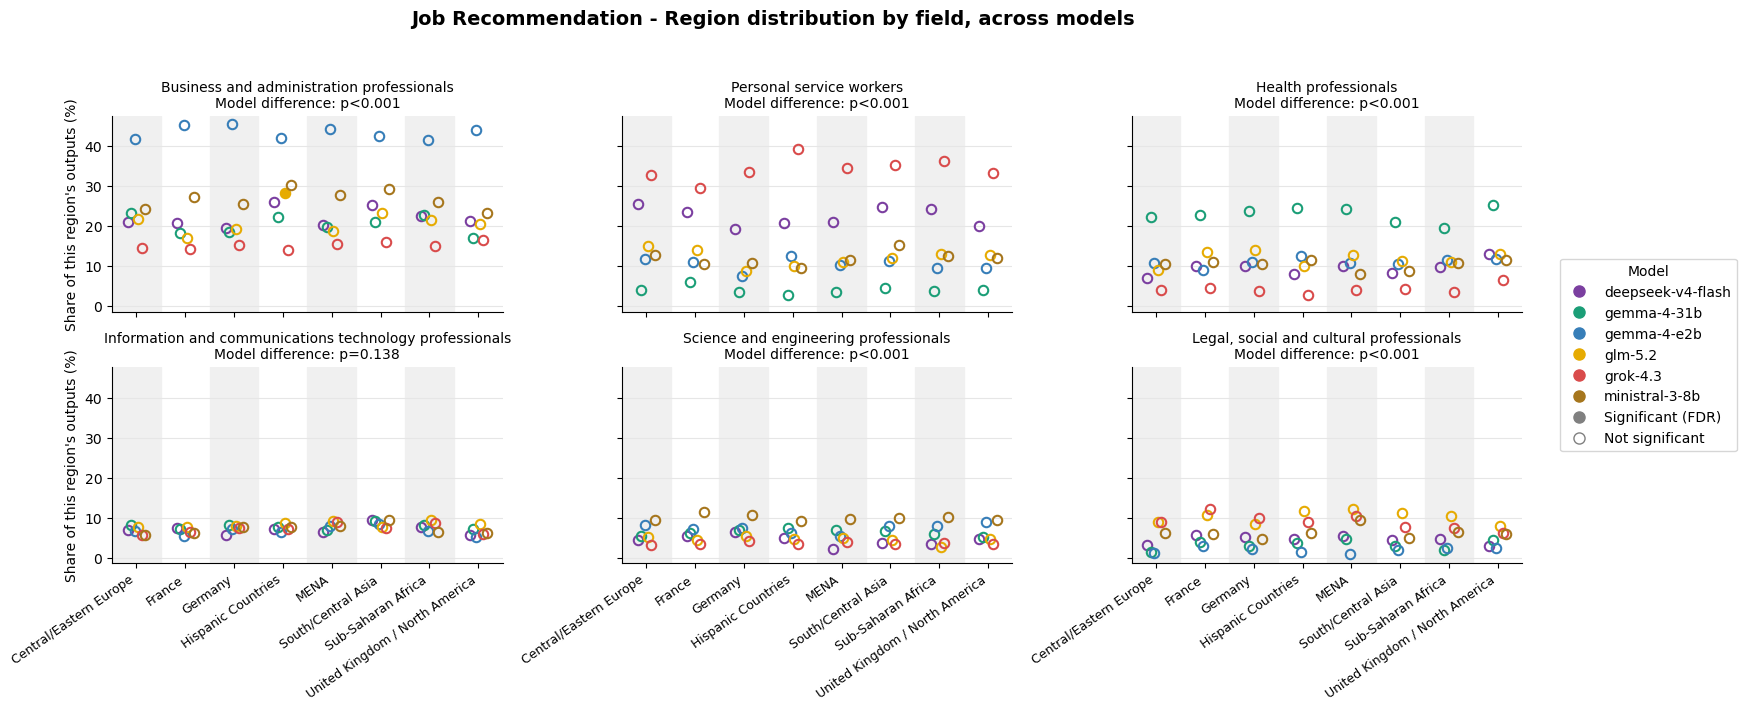

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_q2_college_recommendation.png


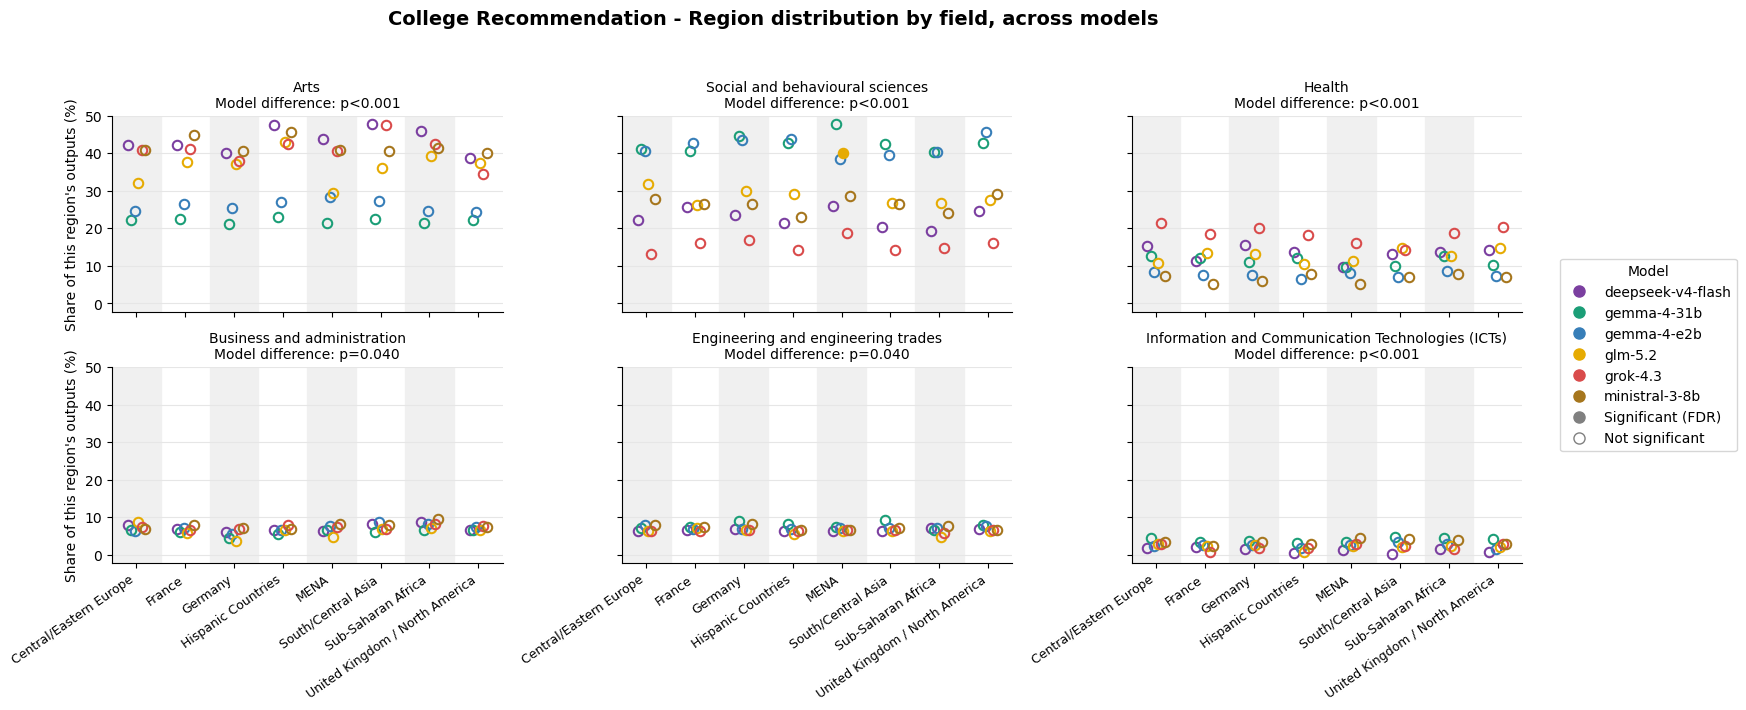

In [6]:
for q in sorted(df["question_key"].unique()):
    region_smallmultiples(df, q)

In [7]:
def region_smallmultiples_plain(df: pd.DataFrame, question: str, n_cols=3):
    """Version WITHOUT p-values between models: just dots filled by significance (Fisher)."""
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(top_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(top_cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        # Alternating vertical bands to separate regions
        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=6.8,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.5, zorder=3)

        ax.set_title(cat, fontsize=10.5)
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=35, ha="right", fontsize=9)
        ax.grid(axis="y", color="0.9", zorder=0)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share of this region's outputs (%)", fontsize=10)

    for ax in axes[len(top_cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models",
                 fontsize=14, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    fig.legend(handles=handles, title="Model", loc="center left",
               bbox_to_anchor=(1.0, 0.5), fontsize=10, title_fontsize=10)

    fig.tight_layout(rect=[0, 0, 0.99, 0.95])
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    out = (OUTPUT_DIR / f"region_smallmultiples_PLAIN_{question}_{title.lower().replace(' ', '_')}.png").resolve()
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

In [8]:
def prepare_region_data(df: pd.DataFrame, question: str) -> pd.DataFrame:
    """Race (=Region) rows with share % and log2(odds ratio) region vs rest."""
    sub = df[(df["question_key"] == question) & (df["attribute"] == "Race")].copy()
    sub = sub[~sub["group_value"].isin(EXCLUDE_REGIONS)]

    sub["share_pct"] = sub["group_in_category"] / sub["group_total"] * 100

    # log2 odds ratio: this region vs all others, Haldane correction (+0.5)
    a = sub["group_in_category"] + 0.5
    b = sub["group_outside_category"] + 0.5
    c = sub["other_in_category"] + 0.5
    d = sub["other_outside_category"] + 0.5
    sub["log2_or"] = np.log2((a / b) / (c / d))

    sub["significant"] = sub["reject_fdr"].astype(bool)
    sub = sub.rename(columns={"group_value": "region"})
    return sub

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_OR_q1_job_recommendation.png


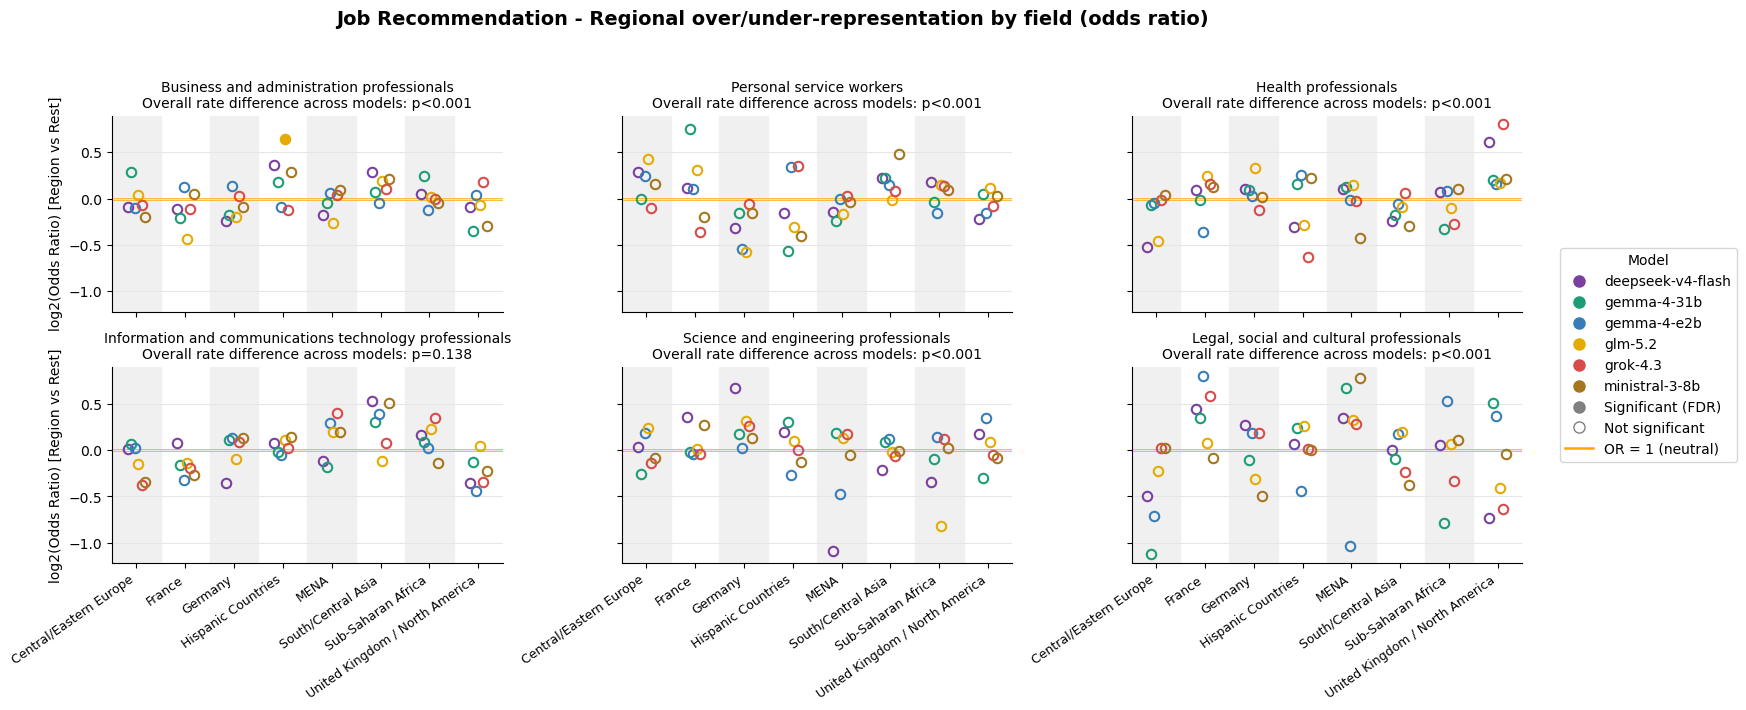

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_OR_PLAIN_q1_job_recommendation.png


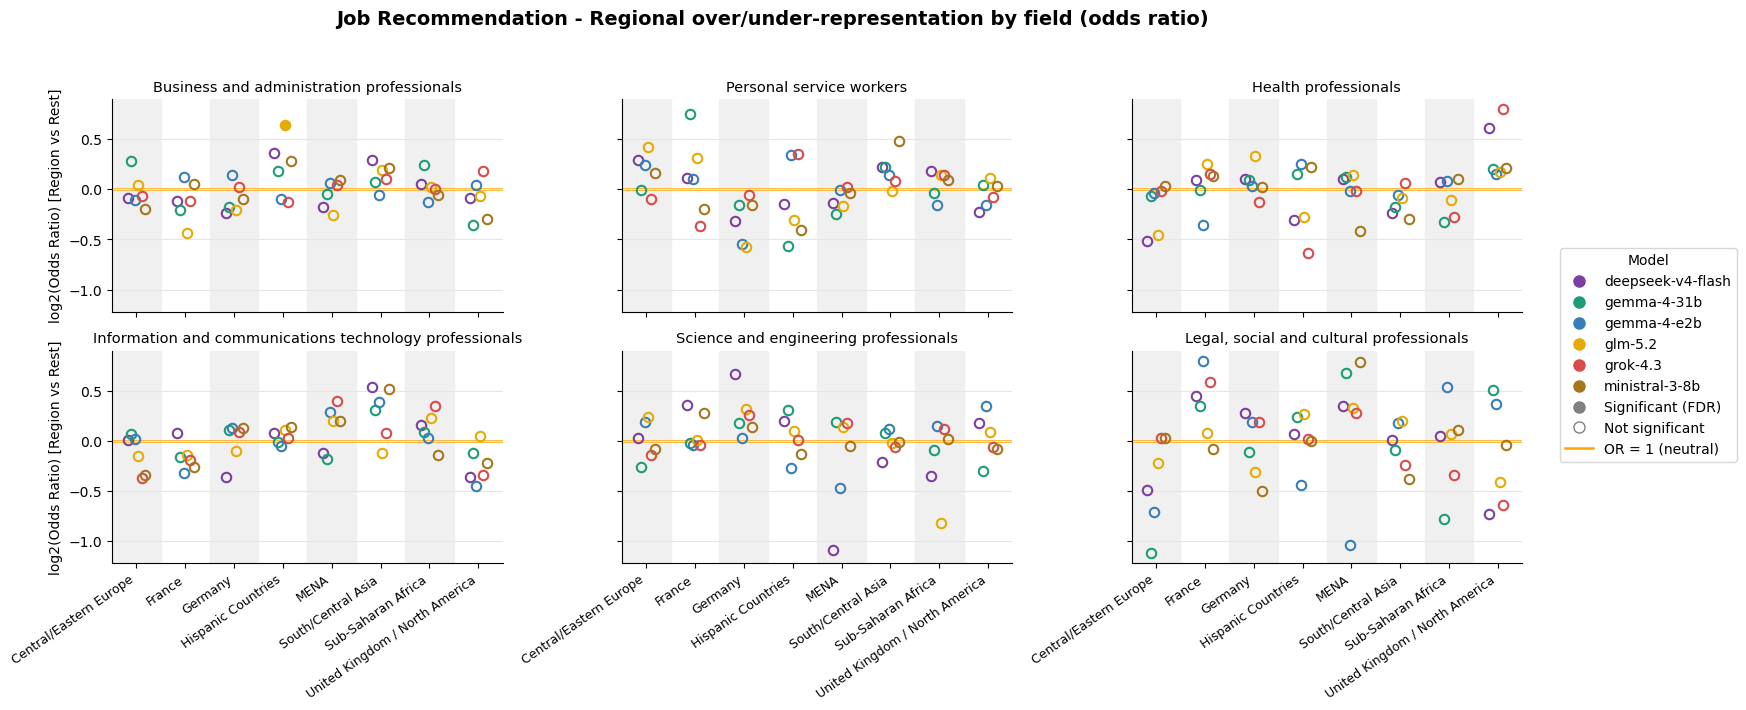

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_OR_q2_college_recommendation.png


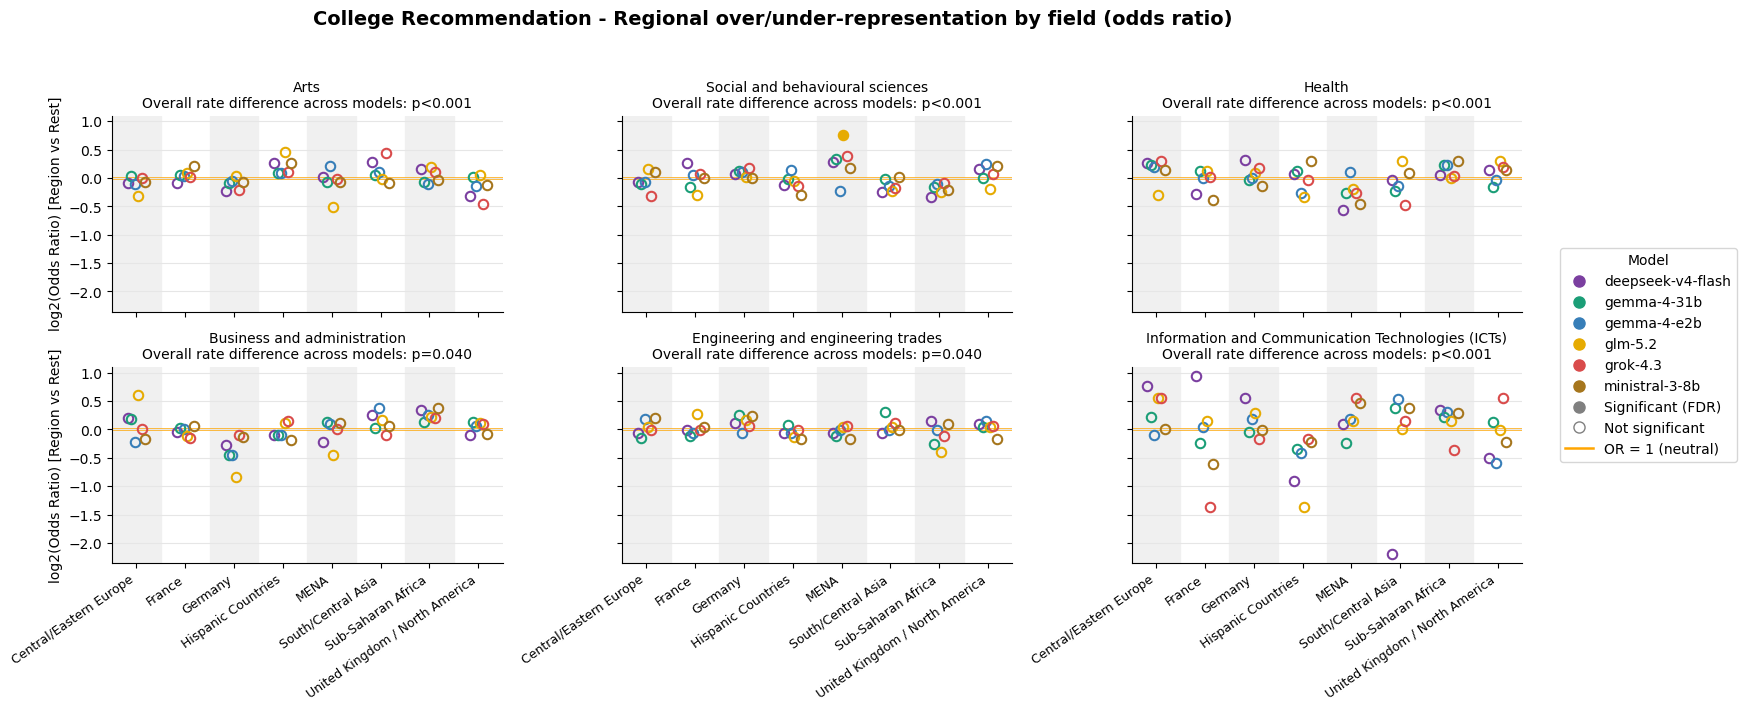

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_OR_PLAIN_q2_college_recommendation.png


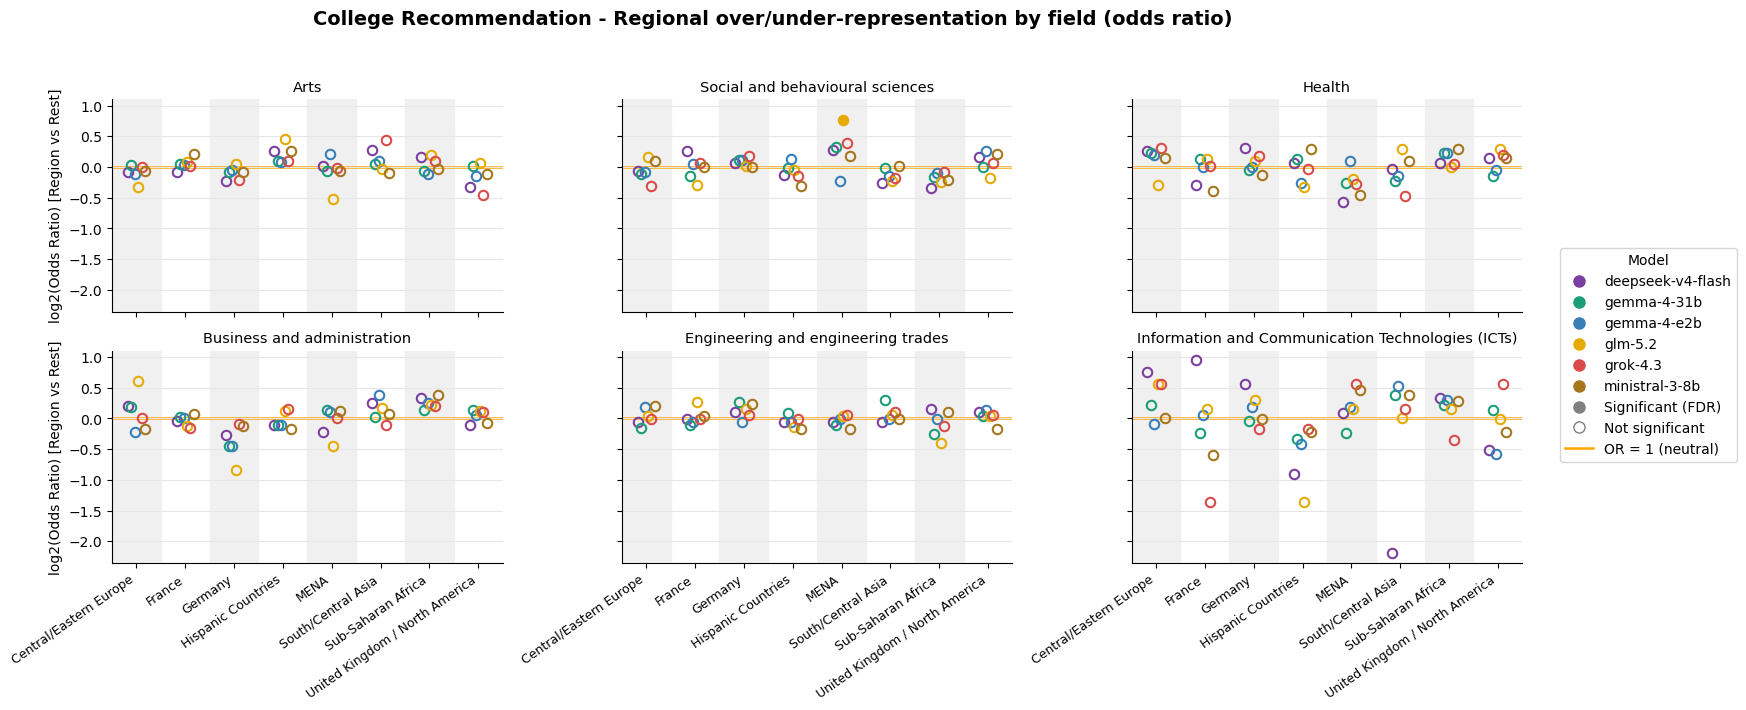

In [9]:
def region_smallmultiples_or(df: pd.DataFrame, question: str, annotate=True, n_cols=3):
    """Small multiples of log2(Odds Ratio) region vs rest, per category.
       annotate=True adds the p-value for the difference between models to the title."""
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )

    if annotate:
        bm = between_model_rate_tests(df, question).set_index("category_value")

        def _fmt(p):
            return "n/a" if pd.isna(p) else ("p<0.001" if p < 0.001 else f"p={p:.3f}")

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(top_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(top_cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        # Alternating vertical bands to separate regions
        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        # Reference line for neutral OR
        ax.axhline(0, color="orange", linewidth=1.8, zorder=1)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["log2_or"], marker="o", linestyle="none",
                        markersize=6.8,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.5, zorder=3)

        if annotate:
            p1 = bm.loc[cat, "p_overall_rate_fdr"] if cat in bm.index else np.nan
            ax.set_title(f"{cat}\nOverall rate difference across models: {_fmt(p1)}",
                         fontsize=10)
        else:
            ax.set_title(cat, fontsize=10.5)

        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=35, ha="right", fontsize=9)
        ax.grid(axis="y", color="0.9", zorder=0)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("log2(Odds Ratio) [Region vs Rest]", fontsize=10)

    for ax in axes[len(top_cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Regional over/under-representation by field (odds ratio)",
                 fontsize=14, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=8,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
        Line2D([], [], color="orange", linewidth=1.8, label="OR = 1 (neutral)"),
    ]
    fig.legend(handles=handles, title="Model", loc="center left",
               bbox_to_anchor=(1.0, 0.5), fontsize=10, title_fontsize=10)

    fig.tight_layout(rect=[0, 0, 0.99, 0.95])
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    tag = "OR" if annotate else "OR_PLAIN"
    out = (OUTPUT_DIR / f"region_smallmultiples_{tag}_{question}_{title.lower().replace(' ', '_')}.png").resolve()
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()


for q in sorted(df["question_key"].unique()):
    region_smallmultiples_or(df, q, annotate=True)
    region_smallmultiples_or(df, q, annotate=False)

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_NOSIG_q1_job_recommendation.png


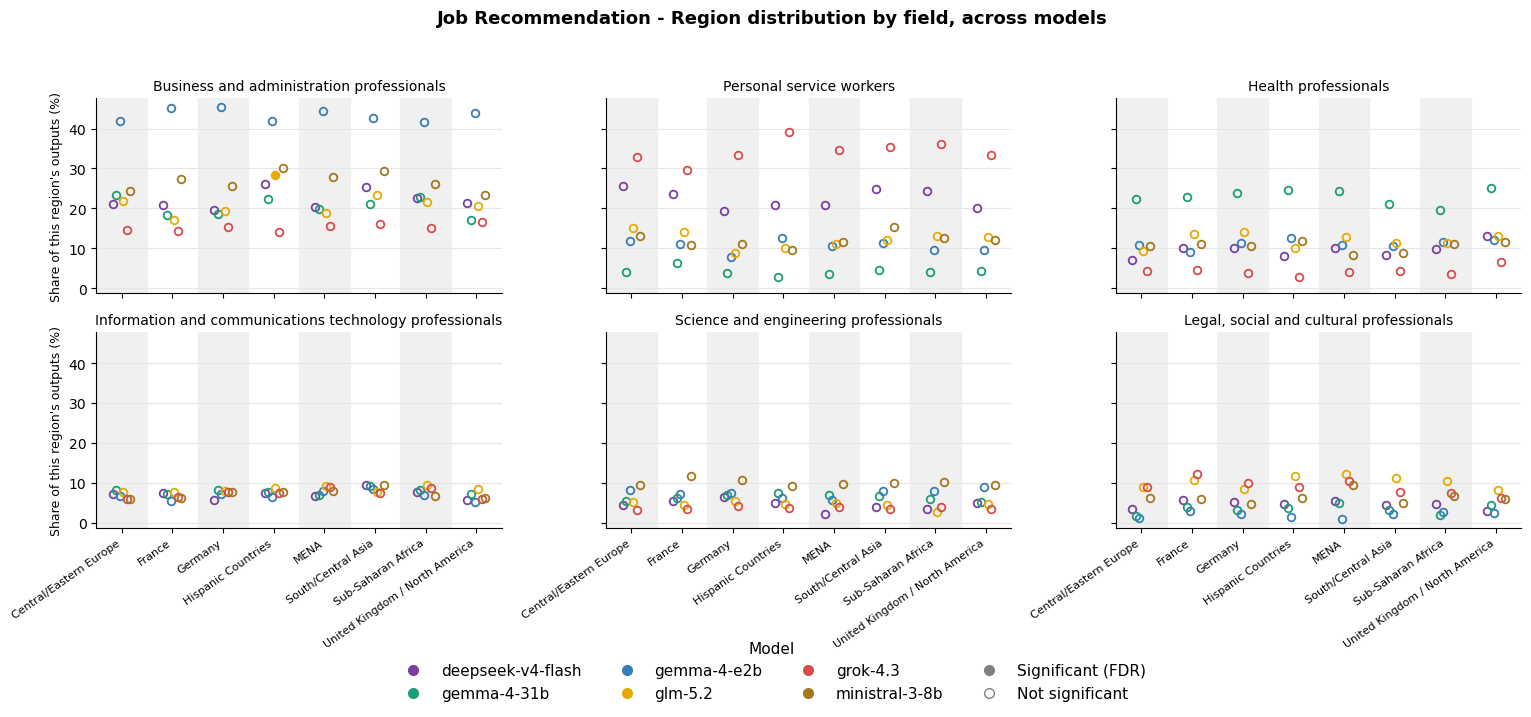

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_NOSIG_q2_college_recommendation.png


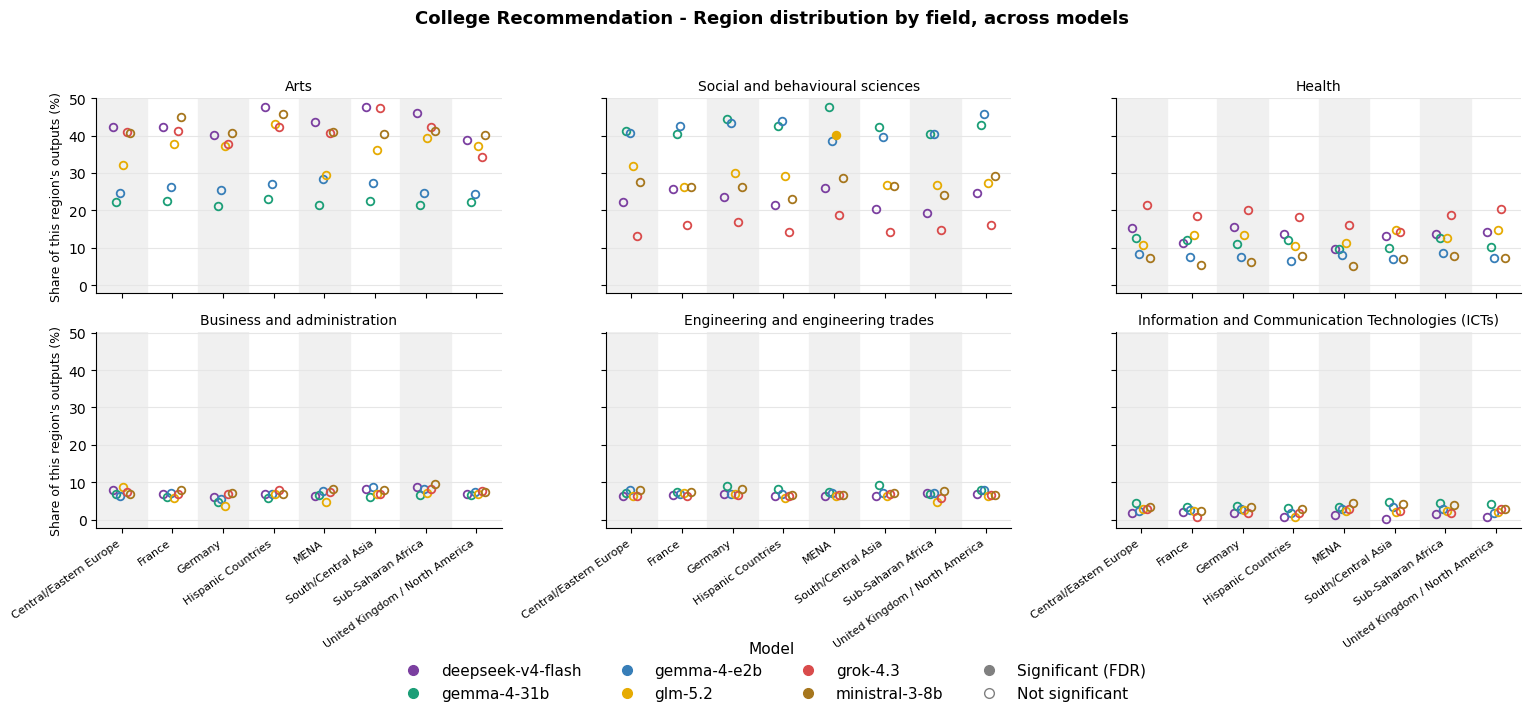

In [10]:
def region_smallmultiples_nosig(df: pd.DataFrame, question: str, n_cols=3):
    """Small multiples of shares by region, WITHOUT model-difference annotation."""
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    top_cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).head(TOP_N).index.tolist()
    )

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(top_cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.6 * n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(top_cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        # Alternating vertical bands by region
        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=5.5,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.3, zorder=3)

        ax.set_title(cat, fontsize=10)   # field name only, no p-value
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=35, ha="right", fontsize=8)
        ax.grid(axis="y", color="0.9", zorder=1)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share of this region's outputs (%)", fontsize=9)

    for ax in axes[len(top_cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models",
                 fontsize=13, fontweight="bold")

    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    # 2 rows -> significance markers stack in the same (last) column
    fig.legend(handles=handles, title="Model", loc="lower center",
               bbox_to_anchor=(0.5, 0.0), ncol=(len(handles) + 1) // 2,
               fontsize=11, title_fontsize=11, frameon=False)

    fig.tight_layout(rect=[0, 0.07, 0.99, 0.95])

    out = OUTPUT_DIR / f"region_smallmultiples_NOSIG_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()


for q in sorted(df["question_key"].unique()):
    region_smallmultiples_nosig(df, q)

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_ALLCATS_SIG_q1_job_recommendation.png  (22 categories)


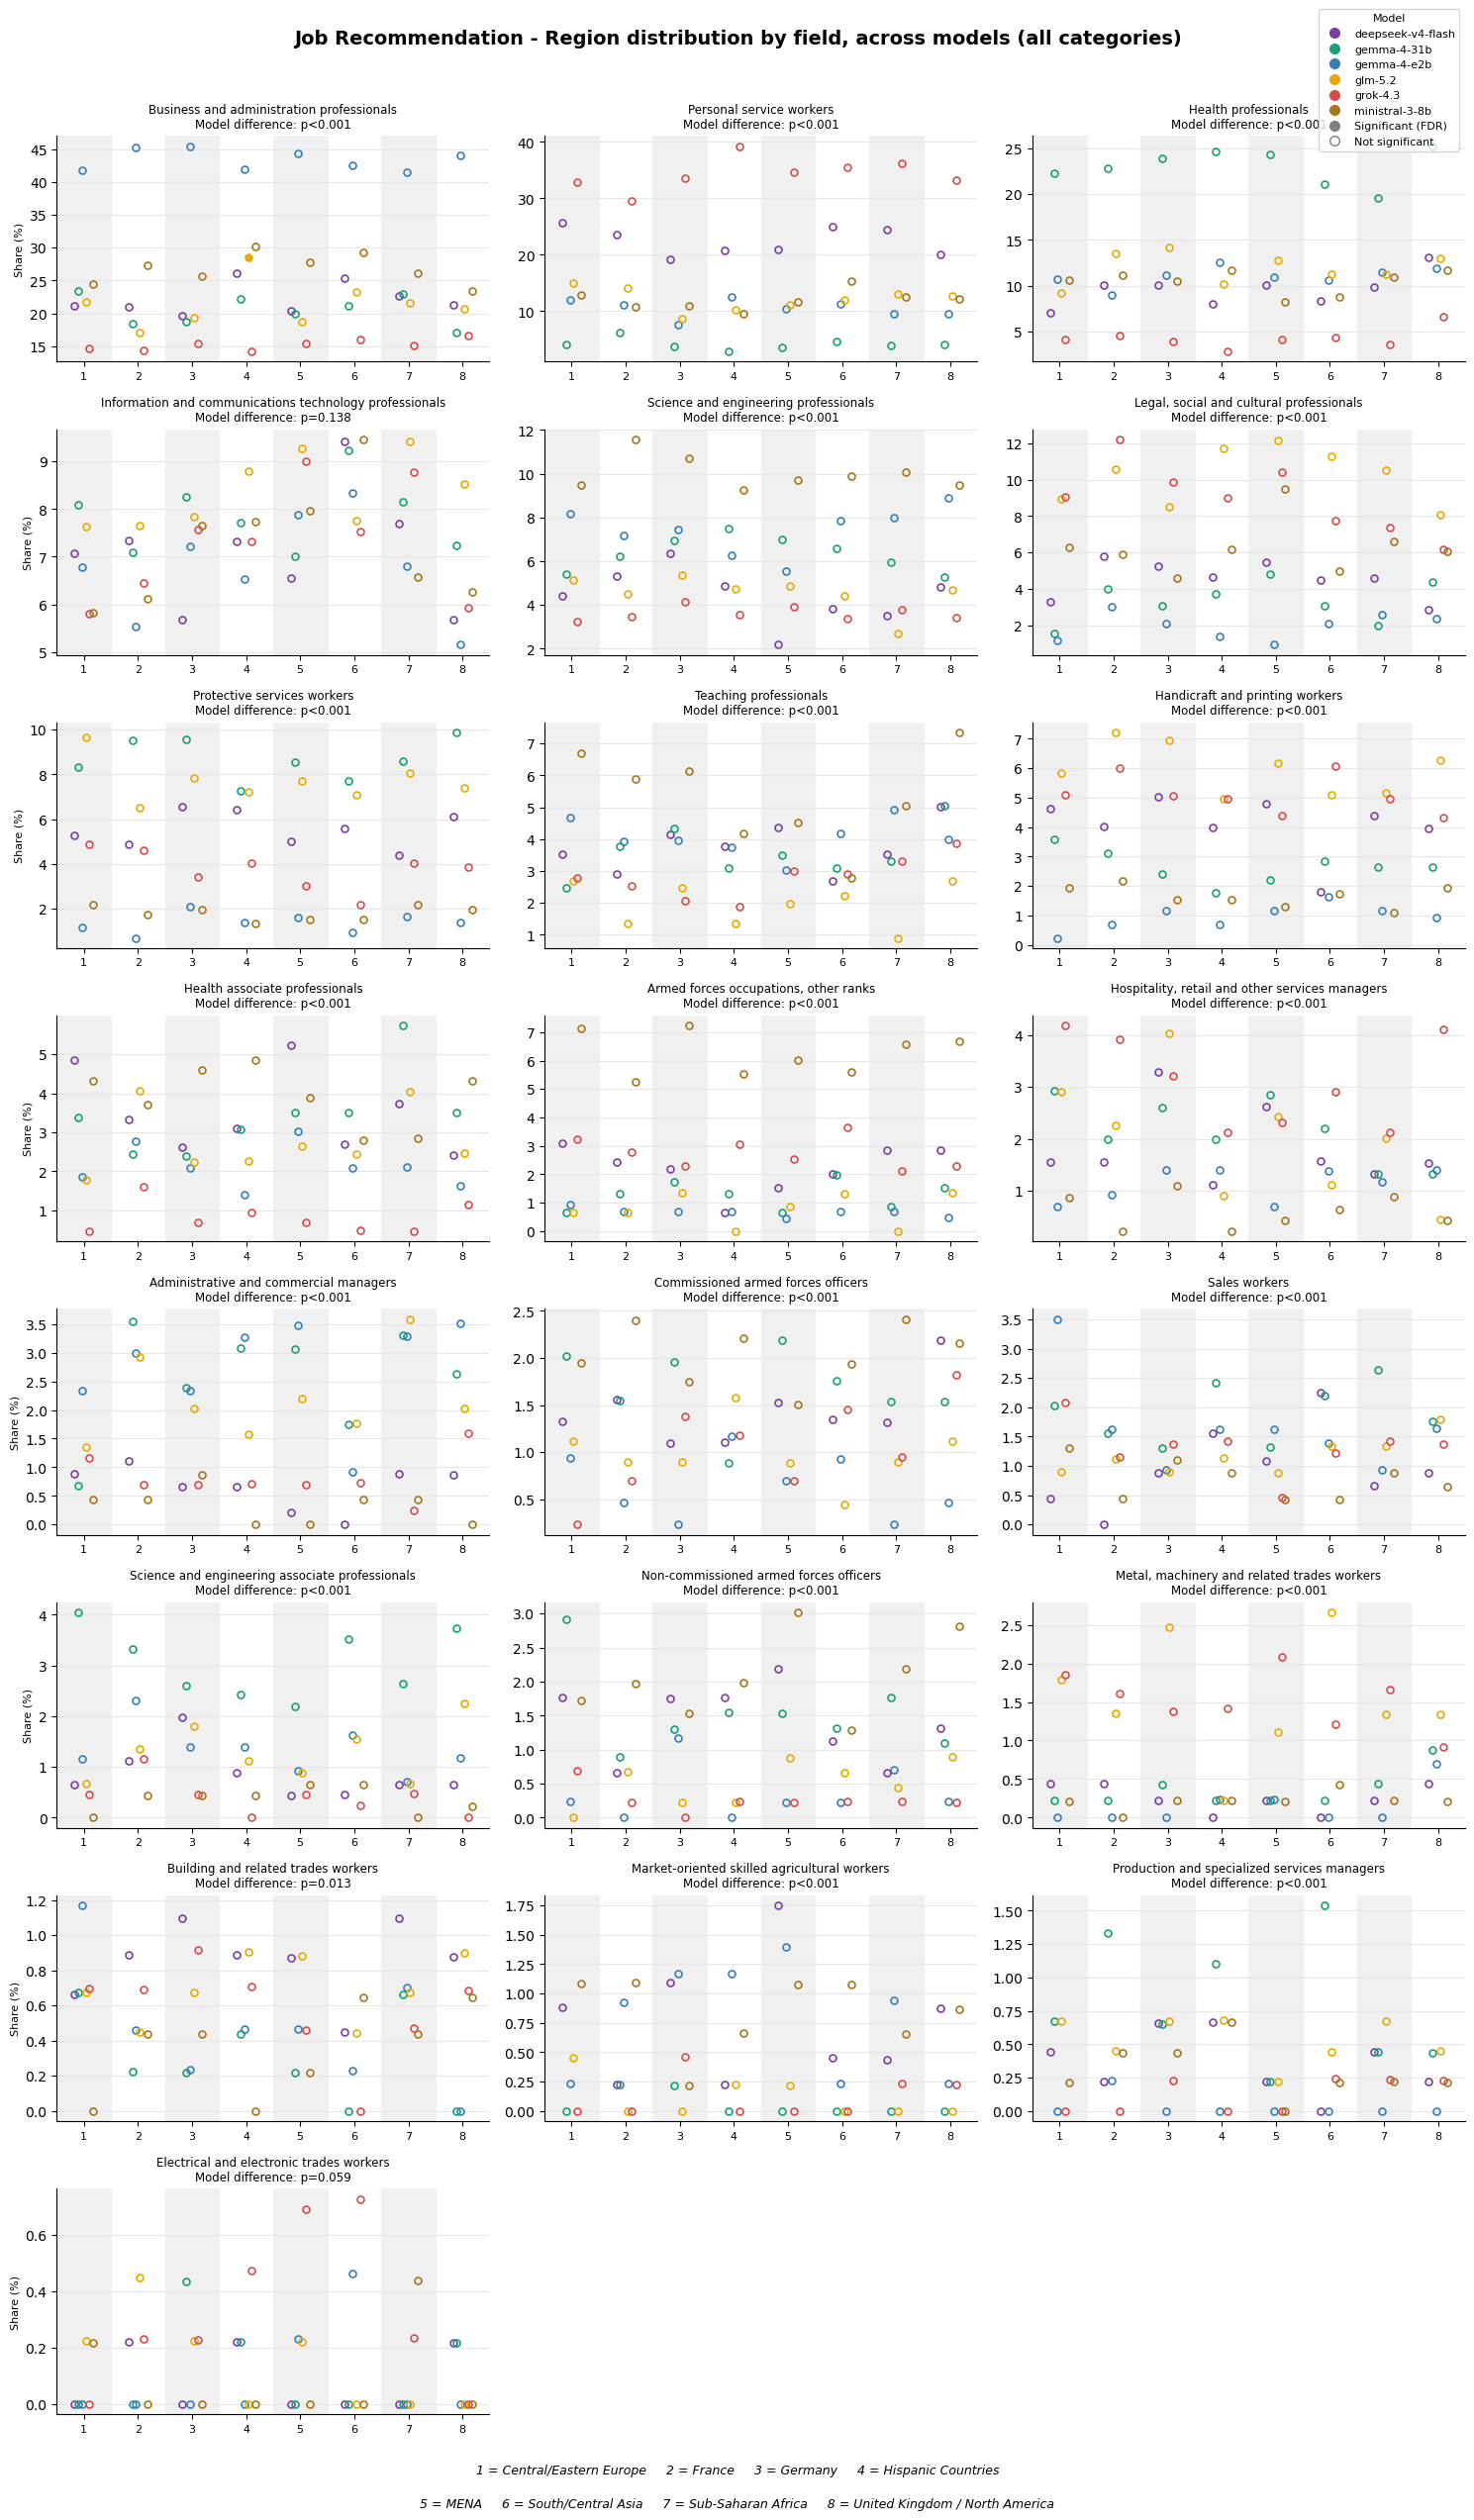

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_ALLCATS_NOSIG_q1_job_recommendation.png  (22 categories)


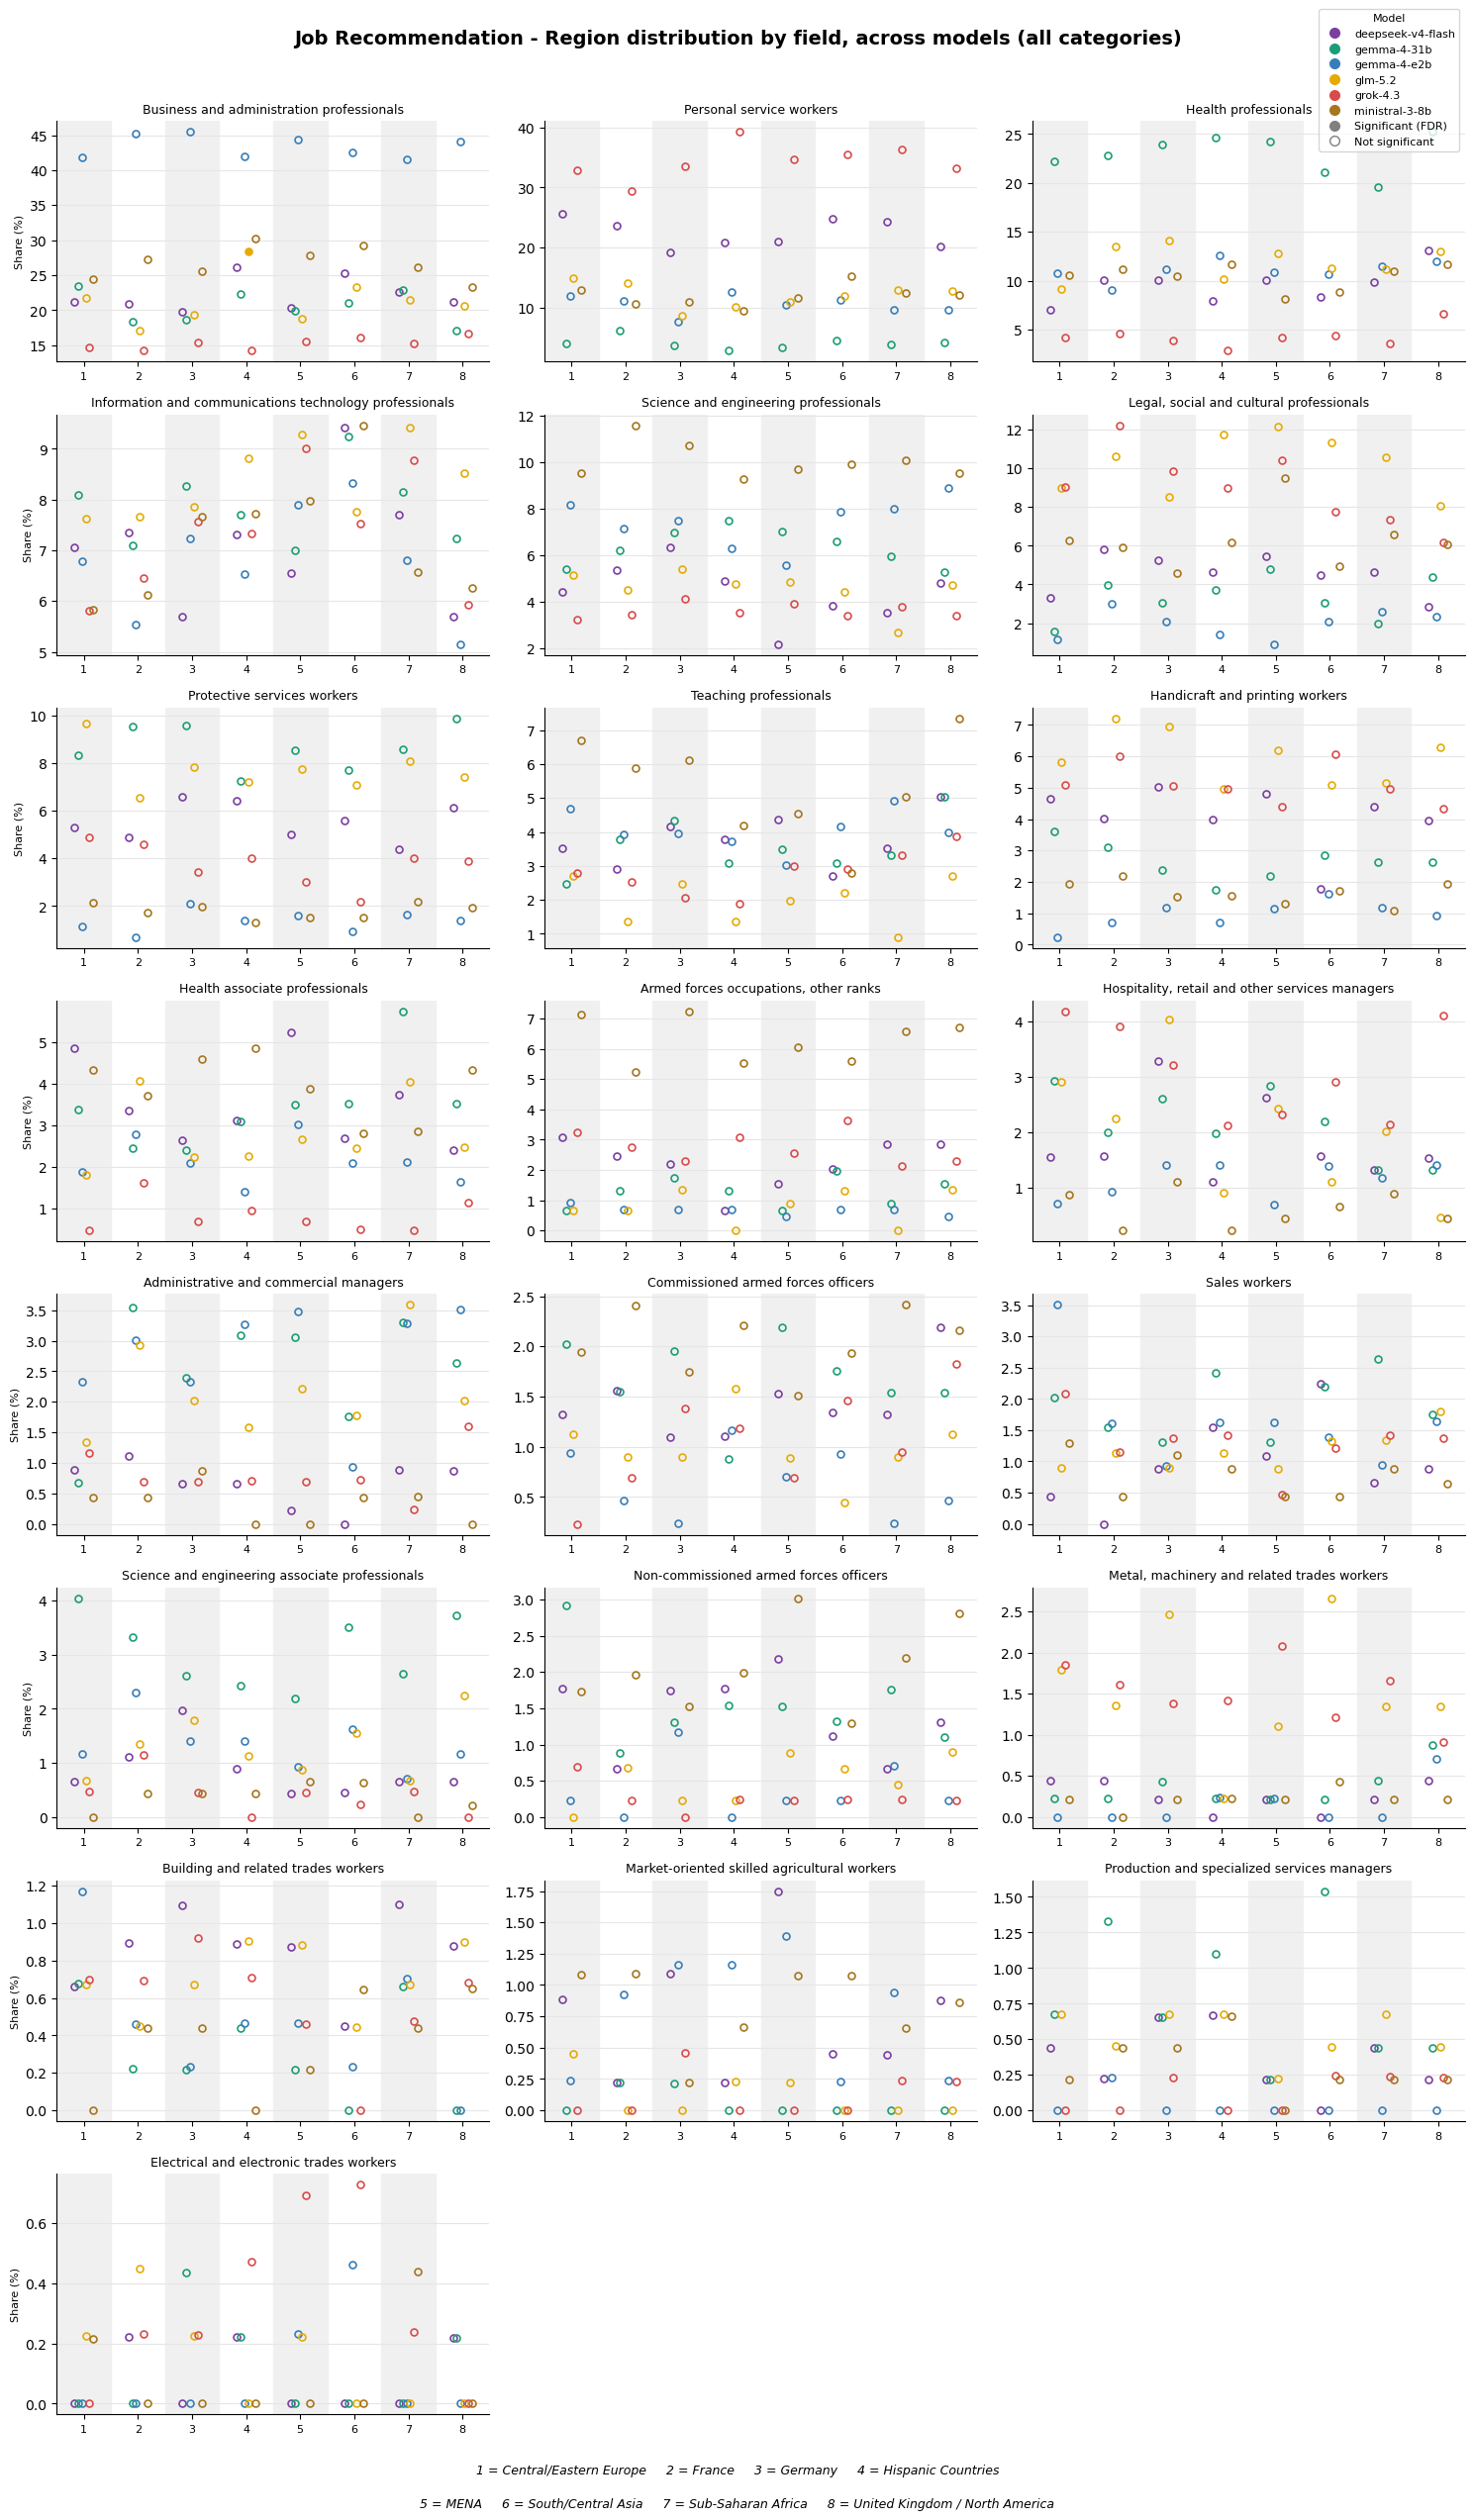

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_ALLCATS_SIG_q2_college_recommendation.png  (14 categories)


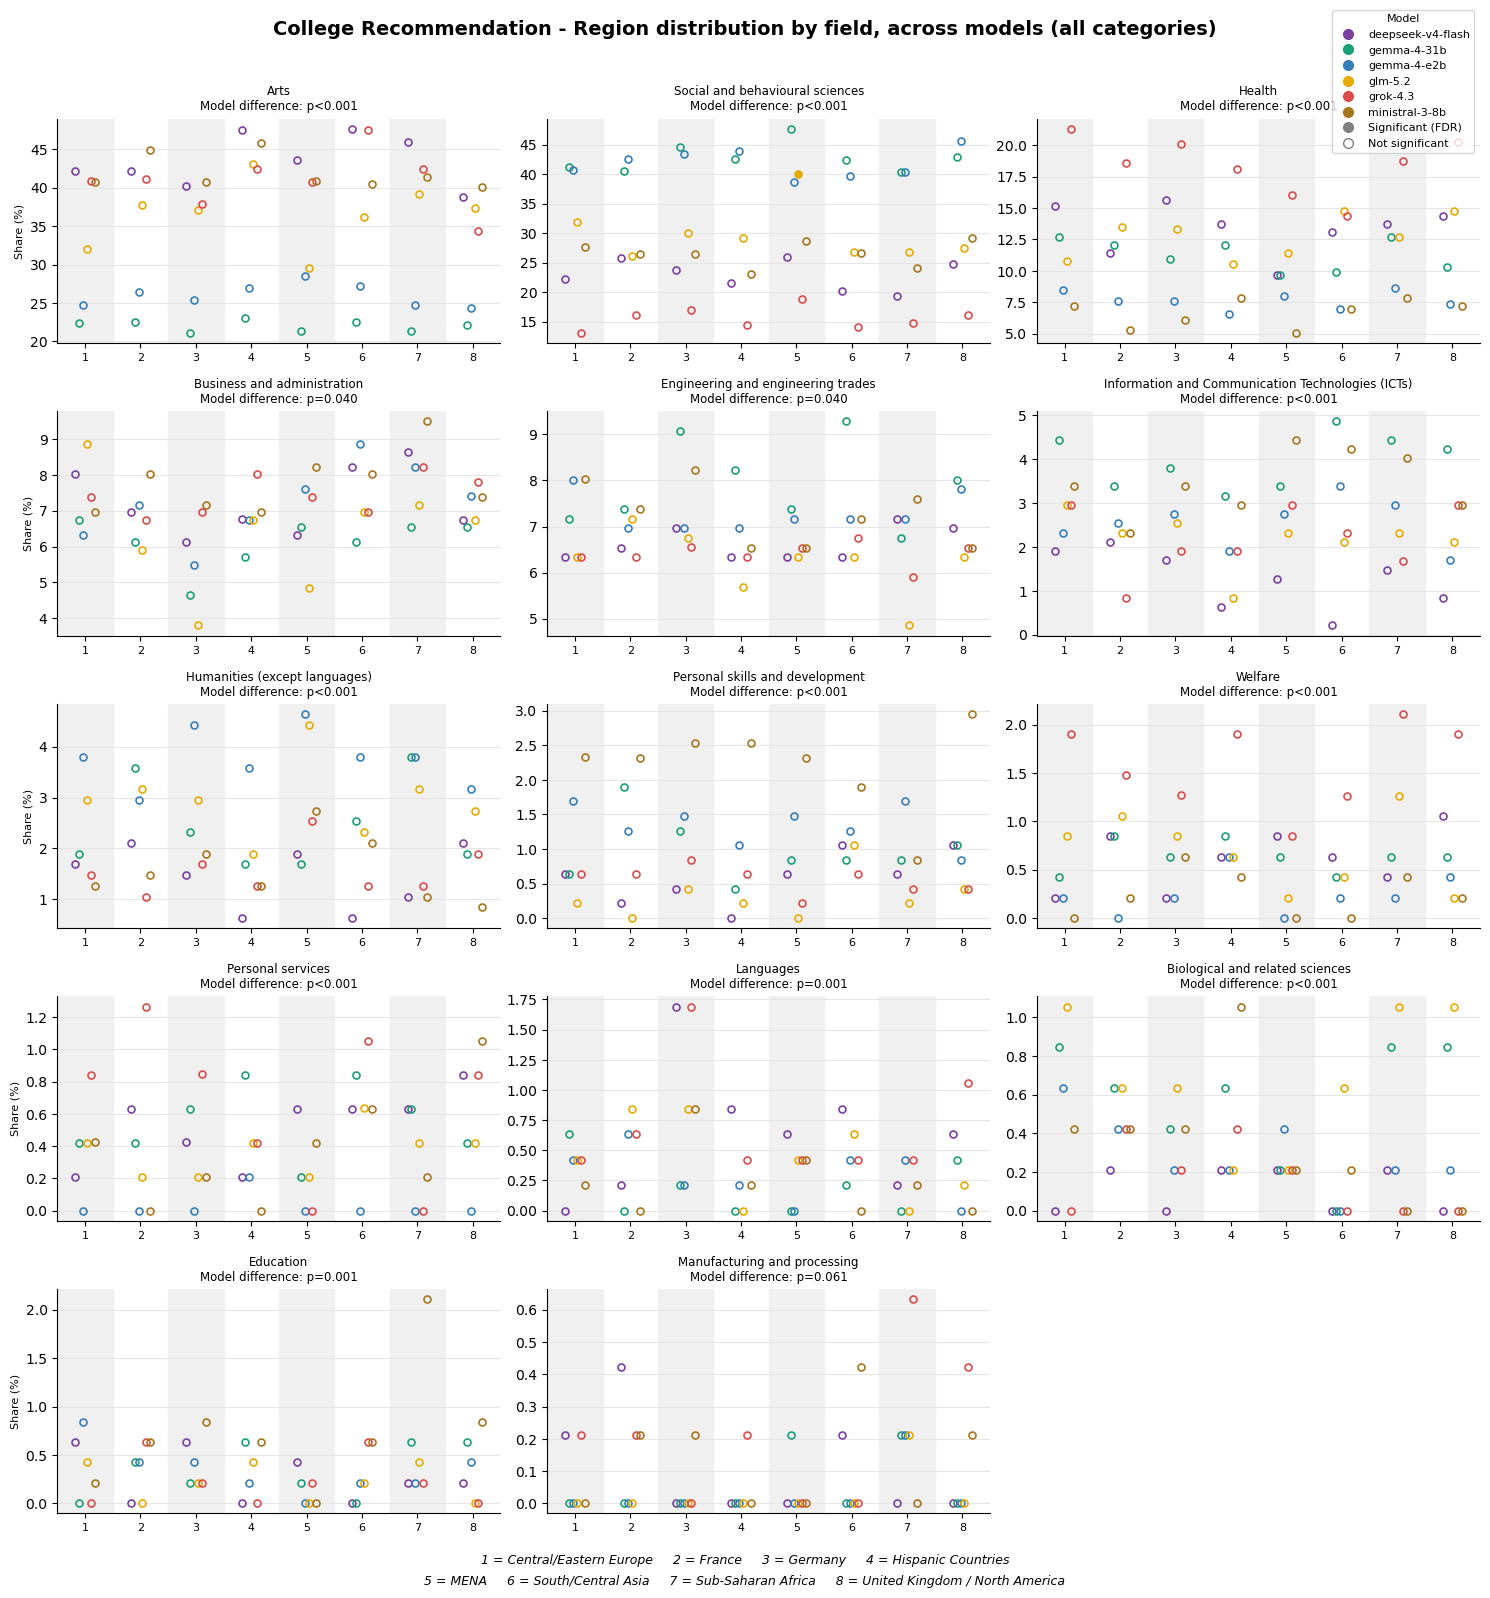

Saved: C:\Users\Javier Miranda\OneDrive\Documentos\University\Team Project\Investigating-Personalization-Effects-in-LLMs\experiments\behavioral_audit\model-comparison-results\figures\region_smallmultiples_ALLCATS_NOSIG_q2_college_recommendation.png  (14 categories)


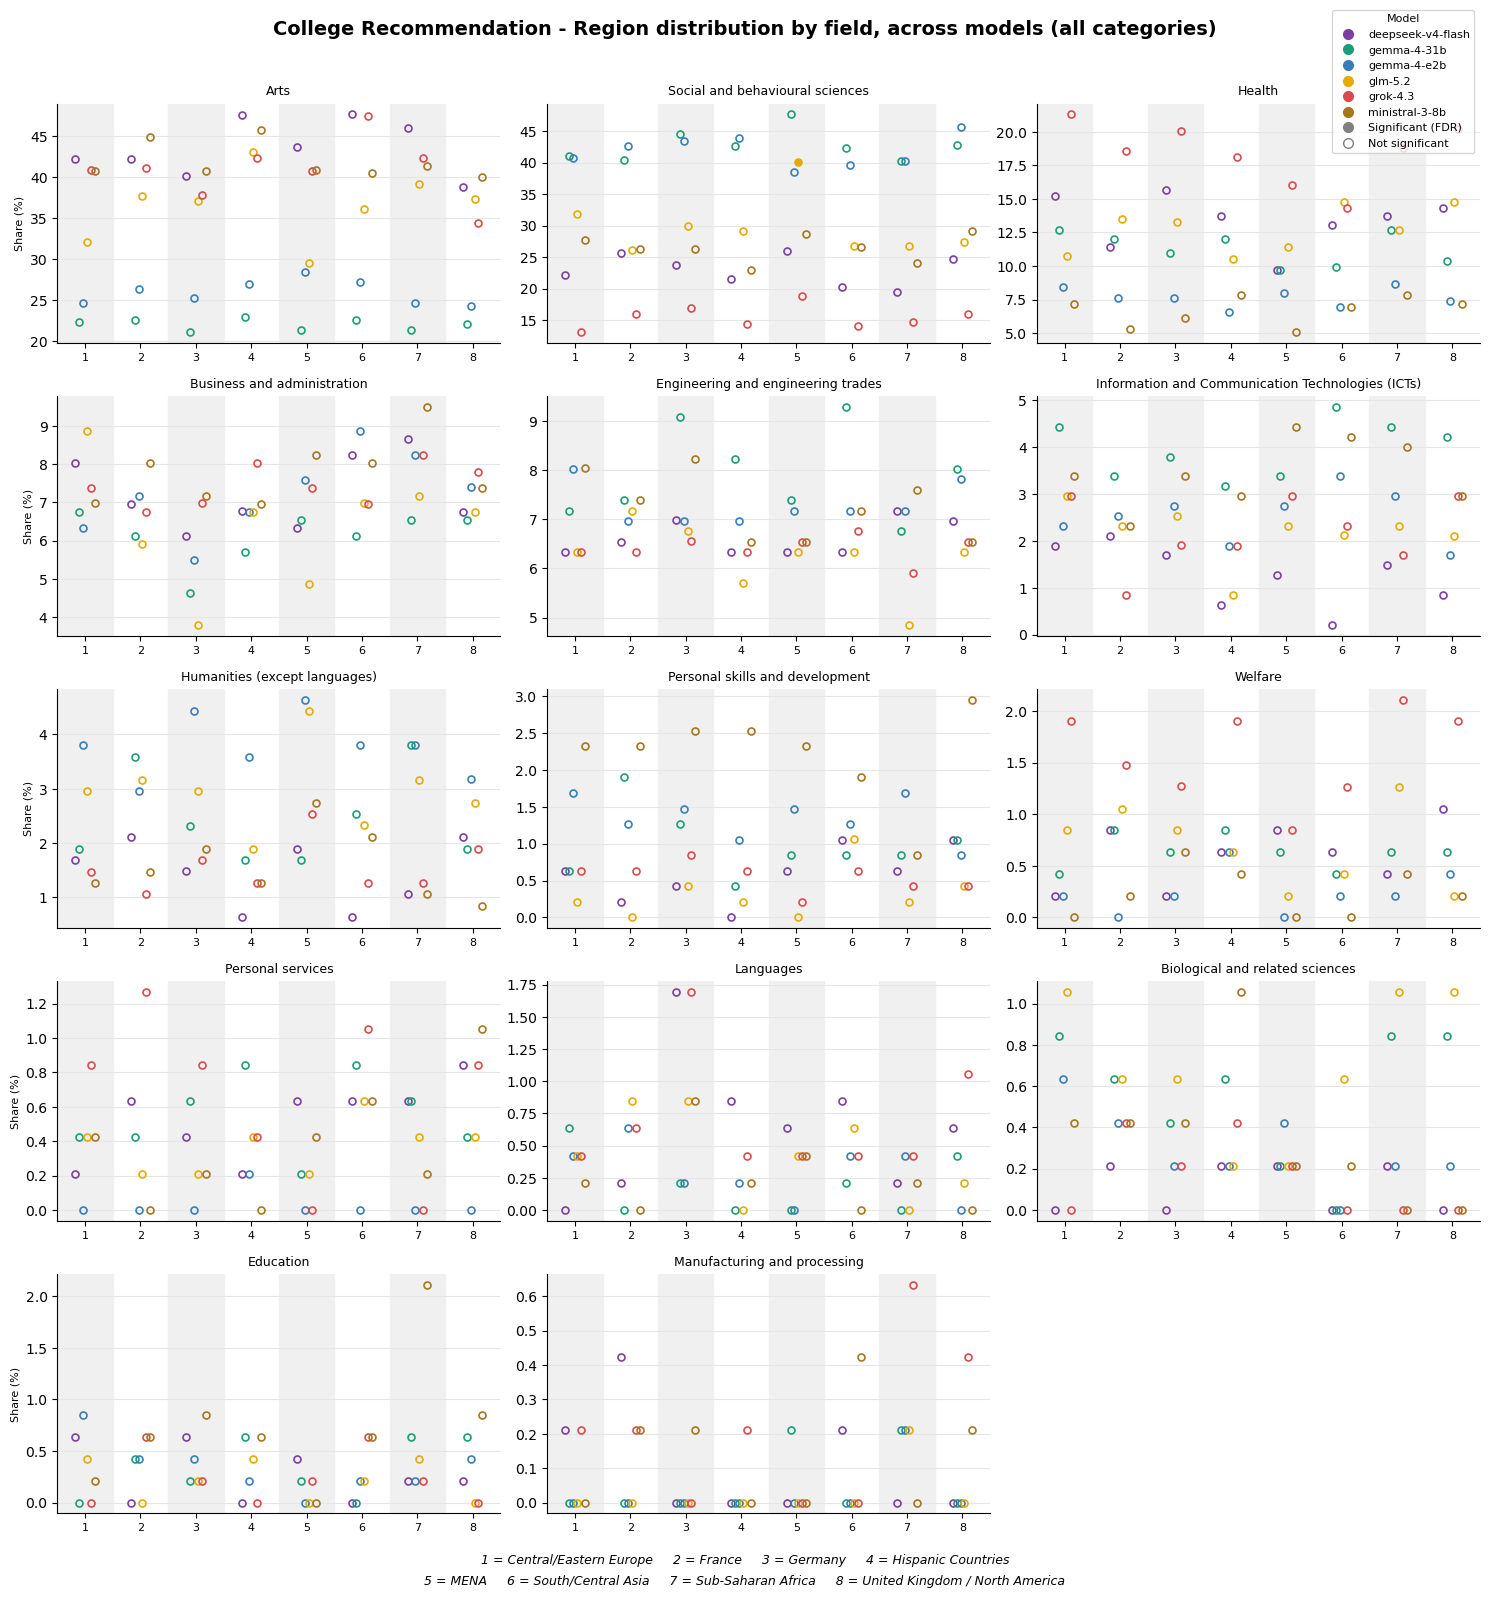

In [11]:
def region_smallmultiples_allcats(df: pd.DataFrame, question: str,
                                  annotate=True, n_cols=3):
    """Small multiples with ALL categories; regions numbered on the X axis
       (visible in every panel) with a numeric legend at the bottom."""
    data = prepare_region_data(df, question)
    if data.empty:
        print(f"[!] No Race/Region data for {question}.")
        return

    models = sorted(data["model_alias"].unique())
    regions = sorted(data["region"].unique())
    region_num = {r: i + 1 for i, r in enumerate(regions)}   # 1..8

    counts = data.groupby("category_value")["model_alias"].nunique()
    shared = counts[counts == len(models)].index
    cats = (
        data[data["category_value"].isin(shared)]
        .groupby("category_value")["category_total"].sum()
        .sort_values(ascending=False).index.tolist()
    )

    if annotate:
        bm = between_model_rate_tests(df, question).set_index("category_value")

        def _fmt(p):
            return "n/a" if pd.isna(p) else ("p<0.001" if p < 0.001 else f"p={p:.3f}")

    title = QUESTION_TITLES.get(question, question)
    n_rows = int(np.ceil(len(cats) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5.0 * n_cols, 3.2 * n_rows),
                             sharex=True)
    axes = np.atleast_1d(axes).flatten()

    x_pos = {r: i for i, r in enumerate(regions)}
    n_models = len(models)
    span = 0.35
    offsets = np.linspace(-span / 2, span / 2, n_models)

    for ci, cat in enumerate(cats):
        ax = axes[ci]
        cdata = data[data["category_value"] == cat]

        # Alternating vertical bands by region
        for ri in range(len(regions)):
            if ri % 2 == 0:
                ax.axvspan(ri - 0.5, ri + 0.5, color="0.94", zorder=0)
        ax.set_xlim(-0.5, len(regions) - 0.5)

        for mi, model in enumerate(models):
            color = MODEL_COLORS.get(model, FALLBACK_COLORS[mi % len(FALLBACK_COLORS)])
            mdata = cdata[cdata["model_alias"] == model]
            for _, row in mdata.iterrows():
                if row["region"] not in x_pos:
                    continue
                x = x_pos[row["region"]] + offsets[mi]
                sig = bool(row["significant"])
                ax.plot(x, row["share_pct"], marker="o", linestyle="none",
                        markersize=5,
                        markerfacecolor=color if sig else "none",
                        markeredgecolor=color, markeredgewidth=1.2, zorder=3)

        if annotate:
            p1 = bm.loc[cat, "p_overall_rate_fdr"] if cat in bm.index else np.nan
            ax.set_title(f"{cat}\nModel difference: {_fmt(p1)}", fontsize=8.5)
        else:
            ax.set_title(cat, fontsize=9)

        # Region numbers on the X axis, visible in ALL panels
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels([str(region_num[r]) for r in regions], fontsize=8)
        ax.tick_params(labelbottom=True)

        ax.grid(axis="y", color="0.9", zorder=1)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        if ci % n_cols == 0:
            ax.set_ylabel("Share (%)", fontsize=8)

    for ax in axes[len(cats):]:
        ax.set_visible(False)

    fig.suptitle(f"{title} - Region distribution by field, across models (all categories)",
                 fontsize=14, fontweight="bold")

    # Model legend
    handles = [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               markeredgecolor=MODEL_COLORS.get(m, FALLBACK_COLORS[i % len(FALLBACK_COLORS)]),
               label=clean_model(m))
        for i, m in enumerate(models)
    ]
    handles += [
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="gray", markeredgecolor="gray", label="Significant (FDR)"),
        Line2D([], [], marker="o", linestyle="none", markersize=7,
               markerfacecolor="none", markeredgecolor="gray", label="Not significant"),
    ]
    fig.legend(handles=handles, title="Model", loc="upper right",
               bbox_to_anchor=(0.99, 0.99), fontsize=8, title_fontsize=8)

    # Number = region lookup table at the bottom (two lines so it isn't cut off)
    items = [f"{n} = {r}" for r, n in region_num.items()]
    half = len(items) // 2 + len(items) % 2
    fig.text(0.5, 0.015, "     ".join(items[:half]),
             ha="center", fontsize=9, style="italic")
    fig.text(0.5, 0.002, "     ".join(items[half:]),
             ha="center", fontsize=9, style="italic")

    fig.tight_layout(rect=[0, 0.025, 1, 0.97])
    tag = "ALLCATS_SIG" if annotate else "ALLCATS_NOSIG"
    out = OUTPUT_DIR / f"region_smallmultiples_{tag}_{question}_{title.lower().replace(' ', '_')}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"Saved: {out}  ({len(cats)} categories)")
    plt.show()


# 4 images: q1/q2 × with/without annotation
for q in sorted(df["question_key"].unique()):
    region_smallmultiples_allcats(df, q, annotate=True)
    region_smallmultiples_allcats(df, q, annotate=False)

In [12]:
def contingency_for_slide(df, question, field):
    """Model × [in/out of field] table with the real values."""
    data = prepare_region_data(df, question)

    # total outputs per model for this question
    totals = (data.drop_duplicates(["model_alias", "region"])
                  .groupby("model_alias")["group_total"].sum())

    cdata = data[data["category_value"] == field]
    in_field = cdata.groupby("model_alias")["group_in_category"].sum()

    table = pd.DataFrame({
        "This Field": in_field,
        "All Other Fields": totals - in_field,
        "Total Row": totals,
    }).fillna(0).astype(int)

    # column-totals row (as in the Fisher slide)
    table.loc["Total Column"] = table.sum()

    print(f"\n{QUESTION_TITLES.get(question, question)} — {field}")
    print(table.to_string())

    # sanity check: the p-value for this exact table
    from scipy.stats import chi2_contingency
    body = table.iloc[:-1, :2].values  # without the totals row/column
    chi2, p, dof, _ = chi2_contingency(body)
    print(f"chi2 = {chi2:.1f}, dof = {dof}, p = {p:.3e}")

    return table


# The field used in the slide example:
contingency_for_slide(df, "q2", "Arts")

# Other candidates to try for the example:
# contingency_for_slide(df, "q2", "Social and behavioural sciences")
# contingency_for_slide(df, "q1", "Personal service workers")


College Recommendation — Arts
                        This Field  All Other Fields  Total Row
model_alias                                                    
deepseek-v4-flash_paid        1650              2140       3790
gemma-4-31b_paid               836              2956       3792
gemma-4-e2b_modal              986              2805       3791
glm-5.2_paid                  1385              2406       3791
grok-4.3_paid                 1551              2240       3791
ministral-3-8b_modal          1588              2203       3791
Total Column                  7996             14750      22746
chi2 = 675.4, dof = 5, p = 1.011e-143


,This Field,All Other Fields,Total Row
model_alias,,,
deepseek-v4-flash_paid,1650,2140,3790
gemma-4-31b_paid,836,2956,3792
gemma-4-e2b_modal,986,2805,3791
glm-5.2_paid,1385,2406,3791
grok-4.3_paid,1551,2240,3791
ministral-3-8b_modal,1588,2203,3791
Total Column,7996,14750,22746
